In [81]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import random
import torch.nn as nn

from astropy.cosmology import Planck18
import astropy.units as u

import sys
sys.path.append("/cephfs/users/soroux/python_libs")


plt.rcParams.update({'font.family': 'Serif', 'font.size': 10})
plt.style.use('tableau-colorblind10')

from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from torch.optim import Adam, SGD
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import random_split

from astropy.cosmology import Planck18 
import astropy.units as u

SEED = 41  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# for GPU reproducibility (if CUDA is available)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# make cuDNN deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

plt.rcParams.update({'font.family': 'Serif', 'font.size': 10})
plt.style.use('tableau-colorblind10')

# enhanced GPU setup w CUDA diagnostics
import os
import subprocess

print("CUDA DIAGNOSTICS")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available in PyTorch: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version (PyTorch): {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Memory: {props.total_memory / 1e9:.1f} GB")
        print(f"  Compute Capability: {props.major}.{props.minor}")
    
    # set device
    run_on = "cuda"
    torch.cuda.set_device(0)  # use first GPU
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    
    # test CUDA functionality
    try:
        test_tensor = torch.tensor([1.0, 2.0, 3.0]).cuda()
        print("CUDA tensor creation successful")
        print(f"Test tensor on GPU: {test_tensor}")
    except Exception as e:
        print(f"CUDA test failed: {e}")
        run_on = "cpu"
        print("Falling back to CPU")
        
else:
    print("CUDA not available in PyTorch")
    
    # check system CUDA
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            print("nvidia-smi available - GPUs detected:")
            print(result.stdout)
        else:
            print("nvidia-smi not available")
    except Exception as e:
        print(f"nvidia-smi failed: {e}")
    
    # check CUDA environment
    cuda_home = os.environ.get('CUDA_HOME')
    cuda_path = os.environ.get('CUDA_PATH')
    print(f"CUDA_HOME: {cuda_home}")
    print(f"CUDA_PATH: {cuda_path}")
    
    run_on = "cpu"
    print("Using CPU")

print(f"Final device: {run_on}")

Random seed set to 41
CUDA DIAGNOSTICS
PyTorch version: 2.7.1+cu118
CUDA available in PyTorch: True
CUDA version (PyTorch): 11.8
Number of GPUs: 8
GPU 0: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 1: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 2: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 3: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 4: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 5: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 6: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
GPU 7: NVIDIA GeForce RTX 2080 Ti
  Memory: 11.3 GB
  Compute Capability: 7.5
Using GPU: NVIDIA GeForce RTX 2080 Ti
CUDA tensor creation successful
Test tensor on GPU: tensor([1., 2., 3.], device='cuda:0')
Final device: cuda


In [82]:
# read the FITS file directly into an astropy Table, then convert to pandas DataFrame
table = Table.read('spiders_quasar_bhmass-DR16-v1.fits')
spiders_catalog = table.to_pandas()
columns_to_keep=['name','RA','DEC','redshift','l_bol1','errl_bol1','l_bol2','errl_bol2','logBHMVP_hb','logBHMA_hb','errlogBHMVP_hb','errlogBHMA_hb','logBHMS_mgII','errlogBHMS_mgII','edd_ratio1','edd_ratio2']
spiders_catalog = spiders_catalog[columns_to_keep]

# define column mappings for redshift-based selection
column_mappings = {
    'l_bol': ('l_bol2', 'l_bol1'),
    'errl_bol': ('errl_bol2', 'errl_bol1'),     
    'logBHM': ('logBHMVP_hb', 'logBHMS_mgII'),
    'errlogBHM': ('errlogBHMVP_hb', 'errlogBHMS_mgII'),
    'edd_ratio': ('edd_ratio2', 'edd_ratio1')
}

# create columns based on redshift condition
for new_col, (low_z_col, high_z_col) in column_mappings.items():
    spiders_catalog[new_col] = np.where(spiders_catalog['redshift'] < 0.6, 
                                       spiders_catalog[low_z_col], 
                                       spiders_catalog[high_z_col])

# drop all the old columns used in the mapping
columns_to_drop = ['l_bol1', 'errl_bol1', 'l_bol2', 'errl_bol2', 
                   'logBHMVP_hb', 'logBHMA_hb', 'errlogBHMVP_hb', 'errlogBHMA_hb', 
                   'logBHMS_mgII', 'errlogBHMS_mgII', 
                   'edd_ratio1', 'edd_ratio2']
spiders_catalog = spiders_catalog.drop(columns=columns_to_drop)

# remove negative values in logBHM or edd_ratio
print(f"Catalog before filtering: {len(spiders_catalog)} objects")
spiders_catalog = spiders_catalog[(spiders_catalog['logBHM'] >= 0) & (spiders_catalog['edd_ratio'] >= 0) & (spiders_catalog['l_bol'] >= 0)]
print(f"Catalog after removing negative logBHM or edd_ratio: {len(spiders_catalog)} objects")
# add normalized log bolometric luminosity: log10(l_bol) - 45 (dex above 1e45 erg/s)
spiders_catalog['logl_bol_norm'] = np.log10(spiders_catalog['l_bol']) - 45.0
spiders_catalog['logBHM_norm'] = spiders_catalog['logBHM'] - 8.5

# keep only the first 1000 sources in the catalog
#spiders_catalog = spiders_catalog.iloc[:1000].reset_index(drop=True)
#keep entire catalog
spiders_catalog = spiders_catalog.reset_index(drop=True)
spiders_catalog

Catalog before filtering: 7670 objects
Catalog after removing negative logBHM or edd_ratio: 7612 objects


,name,RA,DEC,redshift,l_bol,errl_bol,logBHM,errlogBHM,edd_ratio,logl_bol_norm,logBHM_norm
0,b'XMMSL2 J153357.2+470137',233.489186,47.026972,0.392000,4.528477e+45,5.669598e+43,8.567376,0.037969,0.094590,0.655952,0.067376
1,b'XMMSL2 J163545.6+481612',248.940477,48.269926,0.308758,1.784592e+45,2.309242e+43,8.899673,0.057402,0.017669,0.251539,0.399673
2,b'XMMSL2 J163708.7+414019',249.286508,41.671900,0.760000,8.335917e+46,3.442104e+44,9.812540,0.159976,0.098735,1.920953,1.312540
3,b'XMMSL2 J230811.7+200847',347.048549,20.146253,0.249569,1.102674e+45,9.055793e+42,9.332572,0.020081,0.004068,0.042447,0.832572
4,b'XMMSL2 J130258.5+162428',195.744401,16.407824,0.067390,8.049997e+44,3.783529e+42,8.003769,0.006216,0.063723,-0.094204,-0.496231
...,...,...,...,...,...,...,...,...,...,...,...
7607,b'J233135.9-105612 ',352.899720,-10.936890,0.373000,2.407412e+45,4.655697e+43,8.339317,0.087317,0.086098,0.381550,-0.160683
7608,b'J234852.6-091348 ',357.219210,-9.230140,0.462000,8.076617e+45,8.526668e+43,8.825388,0.097979,0.092063,0.907230,0.325388
7609,b'J234644.3-102905 ',356.684840,-10.484860,0.185854,1.439810e+45,1.327323e+43,7.860958,0.026595,0.156520,0.158305,-0.639042
7610,b'J235808.5-102837 ',359.535740,-10.477210,0.169000,1.308319e+45,1.056880e+43,7.427910,0.040855,0.386241,0.116714,-1.072090


In [83]:
neutrino_flux = lambda redshift, lum, logmbh, eddr, *p: lum / (4 * np.pi * Planck18.luminosity_distance(redshift).to(u.cm).value**2) *(logmbh > p[0])* (eddr > p[1]) 
log_neutrino_flux = lambda redshift, lum, logmbh, eddr, *p, ll=-3, norm=11: np.log10(np.maximum(10**norm * neutrino_flux(redshift, lum, logmbh, eddr, *p),10**ll))

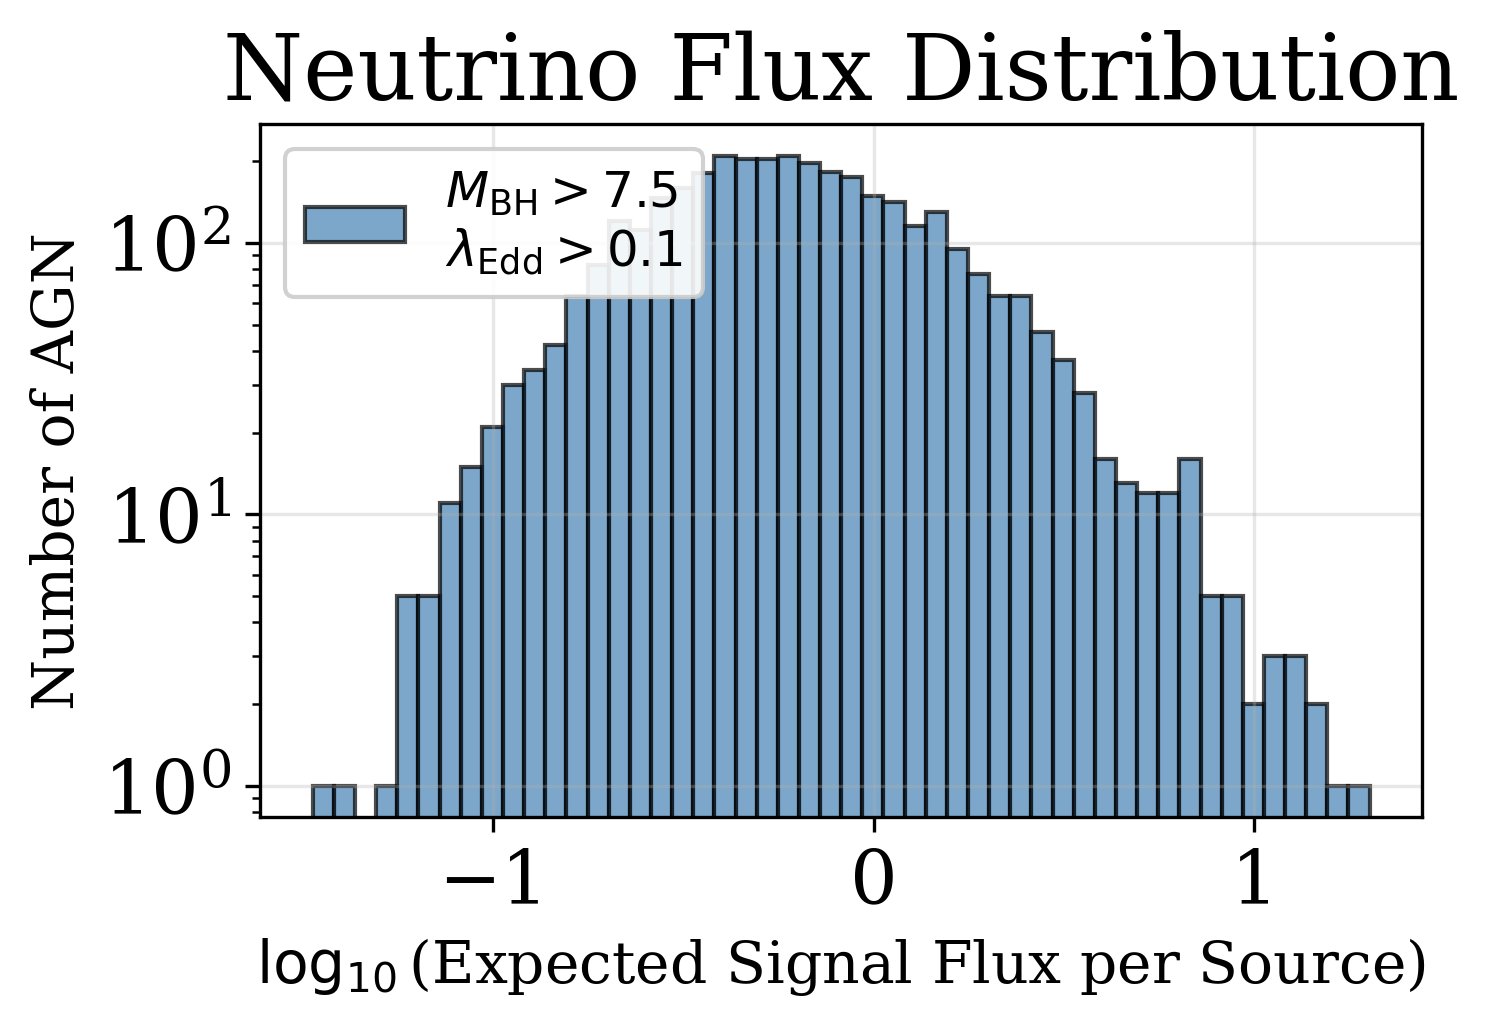

In [84]:
mbh_thres = 7.5
e_ratio_thres = 0.1
nf = log_neutrino_flux(spiders_catalog['redshift'].values, spiders_catalog['l_bol'].values, spiders_catalog['logBHM'].values, spiders_catalog['edd_ratio'].values, mbh_thres, e_ratio_thres)

# filter out inactive sources (those with flux at the lower limit of -3)
# active sources have flux > 10^-3 (log10 > -3)
active_mask = nf > -3
nf_active = nf[active_mask]

plt.figure(figsize=(5, 3),dpi=300)
plt.hist(nf_active, bins=50, alpha=0.7, color='steelblue',edgecolor='black',label=rf'$M_{{\rm BH}} > {mbh_thres}$' + '\n' + rf'$\lambda_{{\rm Edd}} > {e_ratio_thres}$')
plt.xlabel(r'$\log_{10}$(Expected Signal Flux per Source)', fontsize=14)
plt.title('Neutrino Flux Distribution', fontsize=22)
plt.ylabel('Number of AGN', fontsize=14)
plt.tick_params(axis="both", labelsize=18)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
plt.show()

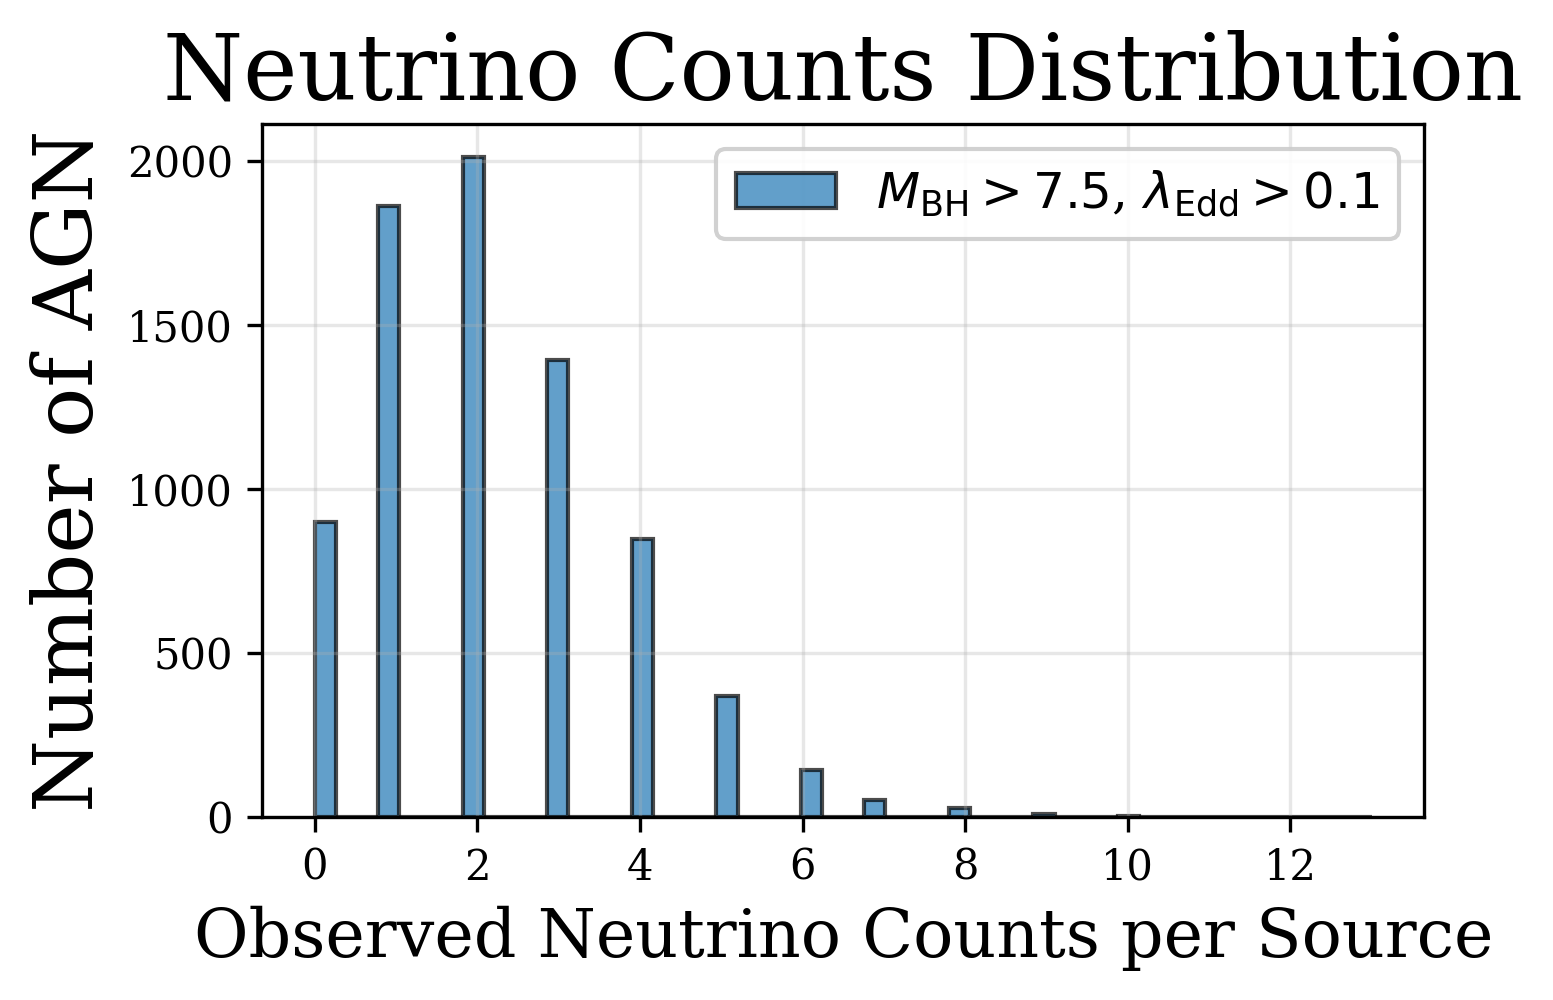

In [85]:
def create_realization(catalog,mbh_thres,e_ratio_thres,norm=[1000, 10000],bg=1):
    """
    Create a realization of the neutrino flux based on the given catalog and thresholds.
    
    Parameters:
    catalog (pd.DataFrame): The input catalog containing 'redshift', 'l_bol', 'logBHM', and 'edd_ratio' columns.
    mbh_thres (float): The black hole mass threshold.
    e_ratio_thres (float): The Eddington ratio threshold.
    norm (float or list): If a scalar, normalization exponent (signal = 10^norm × flux).
        If a list [lo, hi], total signal is normalized log-uniformly in [lo, hi].
    bg (float): Background count rate added to each source.
    
    Returns:
    tuple: (observed_counts, signal, bg)
    """
    flux = neutrino_flux(catalog['redshift'].values, catalog['l_bol'].values, catalog['logBHM'].values, catalog['edd_ratio'].values, mbh_thres, e_ratio_thres)

    if isinstance(norm, (list, tuple)):
        # Normalize total signal to a random value in [norm[0], norm[1]] (log-uniform)
        signal = flux.copy()
        summed_signal = np.sum(signal)
        if summed_signal > 0:
            signal_sum = 10**np.random.uniform(np.log10(norm[0]), np.log10(norm[1]))
            signal *= signal_sum / summed_signal
    else:
        signal = 10**norm * flux

    return np.random.poisson(bg + signal, size=catalog.shape[0]),signal,bg

mbh_thres = 7.5
e_ratio_thres = 0.1
sample,signal,bg = create_realization(spiders_catalog, mbh_thres, e_ratio_thres, norm=[1000, 10000], bg=2.0)
plt.figure(figsize=(5, 3), dpi=300)
plt.hist(sample, bins=50, alpha=0.7, color='tab:blue', edgecolor='black', 
         label=rf'$M_{{\rm BH}} > {mbh_thres}$, $\lambda_{{\rm Edd}} > {e_ratio_thres}$')
plt.title('Neutrino Counts Distribution', fontsize=22)
plt.xlabel('Observed Neutrino Counts per Source',fontsize=16)
plt.ylabel('Number of AGN',fontsize=20)
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()

In [86]:
class CatalogSampleDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset that builds (features, target) pairs from a catalog.
    Targets are generated with create_realization (Poisson neutrino counts).
    """
    def __init__(
        self,
        catalog,
        random_seed = 42,
        nsamples = 100000,
        norm=[1000, 10000],
        bg=1.0,
        feature_cols=None,
        standardize=False,
        device="cpu",
        dtype=torch.float32,
    ):
        self.catalog = catalog.reset_index(drop=True)
        self.feature_cols = feature_cols or ['redshift', 'logl_bol_norm', 'logBHM_norm', 'edd_ratio']
        self.random_seed = random_seed
        np.random.seed(self.random_seed)
        self.mbh_thres = np.random.uniform(6, 9, size=nsamples)
        self.e_ratio_thres = 10**np.random.uniform(-4,0,size=nsamples)
        self.norm = norm
        self.bg = bg
        self.standardize = standardize
        self.device = device
        self.dtype = dtype
        self.nsamples = nsamples

        
        # Features
        X_np = self.catalog[self.feature_cols].values
        self.X = torch.as_tensor(X_np, dtype=self.dtype, device=self.device) # dim = nsources x nfeatures
       
        if self.standardize:
            self.x_mean = self.X.mean(dim=0, keepdim=True)
            self.x_std = self.X.std(dim=0, keepdim=True).clamp_min(1e-12)
            self.X = (self.X - self.x_mean) / self.x_std
        else:
            self.x_mean = None
            self.x_std = None


    def __len__(self):
        return self.nsamples

    def __getitem__(self, idx):
        sample,signal,bg = create_realization(
            self.catalog, self.mbh_thres[idx], self.e_ratio_thres[idx], norm=self.norm, bg=self.bg
        )
        self.y = torch.as_tensor(signal, dtype=self.dtype, device=self.device)
        self.sample = torch.as_tensor(np.log1p(sample), dtype=self.dtype, device=self.device)
        self.input_tensor = torch.cat([self.X, self.sample.unsqueeze(1)], dim=1)
        return self.input_tensor,self.y


class CatalogFMSampleDataset(CatalogSampleDataset):

    def __init__(self,catalog,
        logmbh,
        eddratio,
        norm=[1000, 10000],
        bg=1.0,
        nsamples=1000, device='cpu'):

        super().__init__(catalog,nsamples=nsamples,norm=norm, bg=bg,device=device)
        self.mbh_thres = np.ones(nsamples)*logmbh
        self.e_ratio_thres = np.ones(nsamples)*eddratio

    

# example usage with the prepared catalog and parameters above
train_ds = CatalogSampleDataset(spiders_catalog,bg=2,device=run_on)
data_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
X,y = next(iter(data_loader))

In [87]:
print("Generating observed data...")

# true parameter values (what we'll try to recover)
true_mbh_thres = 8.0  # ξ_{2,i}: log M_BH threshold
true_e_ratio_thres = 0.1  # ξ_{1,i}: λ_Edd threshold
norm = [1000, 10000]  # Total signal drawn log-uniformly from this range
bg = 2.0  # Background level

# generate observed counts using the true parameters
observed_counts, true_signal, true_bg = create_realization(
    spiders_catalog, 
    true_mbh_thres, 
    true_e_ratio_thres, 
    norm=norm, 
    bg=bg
)

# effective total signal used for this realization (needed by the grid scan)
signal_total = np.sum(true_signal)

print(f"  True parameters:")
print(f"    ξ_{{2,i}} (log M_BH threshold) = {true_mbh_thres:.2f}")
print(f"    ξ_{{1,i}} (λ_Edd threshold) = {true_e_ratio_thres:.3f}")
print(f"  Total signal (norm draw): {signal_total:.1f}")
print(f"  Observed counts: min={observed_counts.min()}, max={observed_counts.max()}, mean={observed_counts.mean():.2f}")
print(f"  Number of sources: {len(observed_counts)}")
print()

Generating observed data...
  True parameters:
    ξ_{2,i} (log M_BH threshold) = 8.00
    ξ_{1,i} (λ_Edd threshold) = 0.100
  Total signal (norm draw): 4197.6
  Observed counts: min=0, max=38, mean=2.55
  Number of sources: 7612



In [88]:
print("Creating 2D parameter grid & precomputing flux base...")

# precompute the distance-dependent flux base for each source (independent of ξ_{1,i}, ξ_{2,i})
# flux_base_k = L_bol_k / (4 π d_L(z_k)²)  only depends on source properties
flux_base = spiders_catalog['l_bol'].values / (
    4 * np.pi * Planck18.luminosity_distance(
        spiders_catalog['redshift'].values
    ).to(u.cm).value**2
)
logBHM_arr = spiders_catalog['logBHM'].values
eddr_arr = spiders_catalog['edd_ratio'].values

# grid points
n_grid_points = 50

xi1_range = np.logspace(-3.0, 0.0, n_grid_points)   # λ_Edd threshold [0.001, 1]
xi2_range = np.linspace(6.0, 9.0, n_grid_points)     # log M_BH threshold [6, 9]
XI1_GRID, XI2_GRID = np.meshgrid(xi1_range, xi2_range)

print(f"  Coarse grid: {n_grid_points}×{n_grid_points} = {n_grid_points**2} points")
print(f"  ξ_{{1,i}} range: [{xi1_range.min():.4f}, {xi1_range.max():.4f}]")
print(f"  ξ_{{2,i}} range: [{xi2_range.min():.2f}, {xi2_range.max():.2f}]")
print()

Creating 2D parameter grid & precomputing flux base...
  Coarse grid: 50×50 = 2500 points
  ξ_{1,i} range: [0.0010, 1.0000]
  ξ_{2,i} range: [6.00, 9.00]



In [89]:
print("computing Poisson log-likelihood on coarse grid...")

# using precomputed flux_base (no repeated luminosity-distance calls)
log_likelihood_grid = np.zeros((n_grid_points, n_grid_points))

for j in range(n_grid_points):
    for i in range(n_grid_points):
        xi1_val = xi1_range[i]
        xi2_val = xi2_range[j]

        # forward model: flux pattern normalized to the same total signal budget
        flux_pattern = flux_base * (logBHM_arr > xi2_val) * (eddr_arr > xi1_val)
        sum_flux = np.sum(flux_pattern)
        if sum_flux > 0:
            predicted_signal = signal_total * flux_pattern / sum_flux
        else:
            predicted_signal = np.zeros_like(flux_pattern)

        lam = np.clip(predicted_signal + bg, 1e-20, None)
        log_likelihood_grid[j, i] = np.sum(observed_counts * np.log(lam) - lam)

print(f"  Done. Log-likelihood range: [{log_likelihood_grid.min():.2f}, {log_likelihood_grid.max():.2f}]")
print()

computing Poisson log-likelihood on coarse grid...


  Done. Log-likelihood range: [-5768.03, 889.21]



In [90]:
print("Find MLE on coarse grid, build fine grid, compute posterior")

# MLE from coarse grid 
best_idx = np.unravel_index(np.argmax(log_likelihood_grid), log_likelihood_grid.shape)
coarse_best_xi1 = xi1_range[best_idx[1]]
coarse_best_xi2 = xi2_range[best_idx[0]]
print(f"  Coarse MLE:  ξ_{{1,i}} = {coarse_best_xi1:.4f},  ξ_{{2,i}} = {coarse_best_xi2:.2f}")
print(f"  True values: ξ_{{1,i}} = {true_e_ratio_thres:.4f},  ξ_{{2,i}} = {true_mbh_thres:.2f}")

# fine grid centred on the coarse MLE
n_fine = 500
# width chosen so the relative log-likelihood drops to ≈ -200 at the edges
fine_xi1_range = np.linspace(
    max(0.001, coarse_best_xi1 - 0.10), coarse_best_xi1 + 0.10, n_fine
)
fine_xi2_range = np.linspace(
    max(6.0, coarse_best_xi2 - 0.20), min(9.0, coarse_best_xi2 + 0.20), n_fine
)
FINE_XI1, FINE_XI2 = np.meshgrid(fine_xi1_range, fine_xi2_range)

# Log-likelihood on the fine grid, vectorized inner loop for speed
# Pre-compute ξ₁ (Eddington ratio) masks for all i values: (n_fine, n_sources)
mask_xi1_all = eddr_arr[np.newaxis, :] > fine_xi1_range[:, np.newaxis]
log_obs = observed_counts[np.newaxis, :]   # (1, n_sources) for broadcasting

fine_ll = np.zeros((n_fine, n_fine))
for j in range(n_fine):
    # ξ₂ mask for this row: which sources have logBHM above the threshold
    mask_xi2 = logBHM_arr > fine_xi2_range[j]                    # (n_sources,)
    flux_masked = flux_base * mask_xi2                            # (n_sources,)

    # combine with all ξ₁ thresholds at once → (n_fine, n_sources)
    flux_pattern = flux_masked[np.newaxis, :] * mask_xi1_all

    sum_flux = flux_pattern.sum(axis=1, keepdims=True)            # (n_fine, 1)
    # normalise where sum > 0
    safe_sum = np.where(sum_flux > 0, sum_flux, 1.0)
    sig = np.where(sum_flux > 0, signal_total * flux_pattern / safe_sum, 0.0)

    lam = np.clip(sig + bg, 1e-20, None)                         # (n_fine, n_sources)
    fine_ll[j, :] = np.sum(log_obs * np.log(lam) - lam, axis=1)  # (n_fine,)

print(f"  Fine grid computed ({n_fine}×{n_fine} = {n_fine**2:,} points)")

# relative log values (posterior ∝ likelihood with flat prior)
fine_ll_max = fine_ll.max()
fine_rel_log10 = (fine_ll - fine_ll_max) / np.log(10)   # relative log posterior

best_fine_idx = np.unravel_index(np.argmax(fine_ll), fine_ll.shape)
best_xi1 = fine_xi1_range[best_fine_idx[1]]
best_xi2 = fine_xi2_range[best_fine_idx[0]]

print(f"\n  Fine MLE:    ξ_{{1,i}} = {best_xi1:.4f},  ξ_{{2,i}} = {best_xi2:.4f}")
print(f"  Relative log₁₀ posterior range: [{fine_rel_log10.min():.1f}, {fine_rel_log10.max():.1f}]")

# compute coarse-grid relative log (for the wider view)
coarse_rel_log10 = (log_likelihood_grid - log_likelihood_grid.max()) / np.log(10)
print(f"  Coarse relative log₁₀ range:    [{coarse_rel_log10.min():.1f}, {coarse_rel_log10.max():.1f}]")

# odds ratio: H1 (signal+background) vs H0 (background-only)
n_sources = len(observed_counts)

# bkg-only model: uniform rate = total counts / N_sources
lam_bkg = np.full(n_sources, observed_counts.sum() / n_sources)
lam_bkg = np.clip(lam_bkg, 1e-20, None)
log_L_bkg = np.sum(observed_counts * np.log(lam_bkg) - lam_bkg)

# H1: best-fit signal+background model (at MLE)
log_L_H1 = fine_ll_max   # no prior for the step model

delta_log_L = log_L_H1 - log_L_bkg
TS = 2 * delta_log_L
log10_odds = delta_log_L / np.log(10)

# gaussian-equivalent significance: σ ≈ √TS  (for TS >> 1, 2 DOF)
sigma_equiv = np.sqrt(TS)

# reconstruction quality: predicted signal at MLE vs true signal
flux_mle = flux_base * (logBHM_arr > best_xi2) * (eddr_arr > best_xi1)
sum_flux_mle = np.sum(flux_mle)
predicted_signal_mle = signal_total * flux_mle / sum_flux_mle if sum_flux_mle > 0 else np.zeros_like(flux_mle)
correlation = np.corrcoef(true_signal, predicted_signal_mle)[0, 1]
rmse = np.sqrt(np.mean((predicted_signal_mle - true_signal)**2))

print(f"\nComprehensive Odds Ratio & Quality Metrics")
print(f"  Background-only log-L: {log_L_bkg:.2f}")
print(f"  Best-fit H1 log-L:     {log_L_H1:.2f}")
print(f"  Δ log-L (H1 - H0):    {delta_log_L:.2f}")
print(f"  Test statistic TS=2ΔlogL: {TS:.2f}")
if delta_log_L < 500:
    print(f"  Likelihood ratio (odds): {np.exp(delta_log_L):.2e}")
else:
    print(f"  Likelihood ratio (odds): ~10^{log10_odds:.0f}")
print(f"  log₁₀(odds ratio):     {log10_odds:.1f}")
print(f"  Gaussian-equiv σ:       {sigma_equiv:.1f}σ")
print(f"\n  --- Reconstruction Quality (MLE vs True Signal) ---")
print(f"  Correlation:            {correlation:.4f}")
print(f"  RMSE:                   {rmse:.4f}")
print()

# normalized posterior density 
posterior_unnorm = np.exp(fine_ll - fine_ll_max)           # numerical stability
dxi1 = fine_xi1_range[1] - fine_xi1_range[0]
dxi2 = fine_xi2_range[1] - fine_xi2_range[0]
posterior_density = posterior_unnorm / (np.sum(posterior_unnorm) * dxi1 * dxi2)
print(f"  Posterior density integral check: {np.sum(posterior_density) * dxi1 * dxi2:.6f}")
print(f"  Peak posterior density:           {posterior_density.max():.4f}")
print()

Find MLE on coarse grid, build fine grid, compute posterior
  Coarse MLE:  ξ_{1,i} = 0.1048,  ξ_{2,i} = 8.02
  True values: ξ_{1,i} = 0.1000,  ξ_{2,i} = 8.00


  Fine grid computed (500×500 = 250,000 points)

  Fine MLE:    ξ_{1,i} = 0.1002,  ξ_{2,i} = 7.9992
  Relative log₁₀ posterior range: [-654.6, 0.0]
  Coarse relative log₁₀ range:    [-2891.2, 0.0]

Comprehensive Odds Ratio & Quality Metrics
  Background-only log-L: -1215.74
  Best-fit H1 log-L:     928.79
  Δ log-L (H1 - H0):    2144.52
  Test statistic TS=2ΔlogL: 4289.04
  Likelihood ratio (odds): ~10^931
  log₁₀(odds ratio):     931.4
  Gaussian-equiv σ:       65.5σ

  --- Reconstruction Quality (MLE vs True Signal) ---
  Correlation:            1.0000
  RMSE:                   0.0138

  Posterior density integral check: 1.000000
  Peak posterior density:           807652.5660



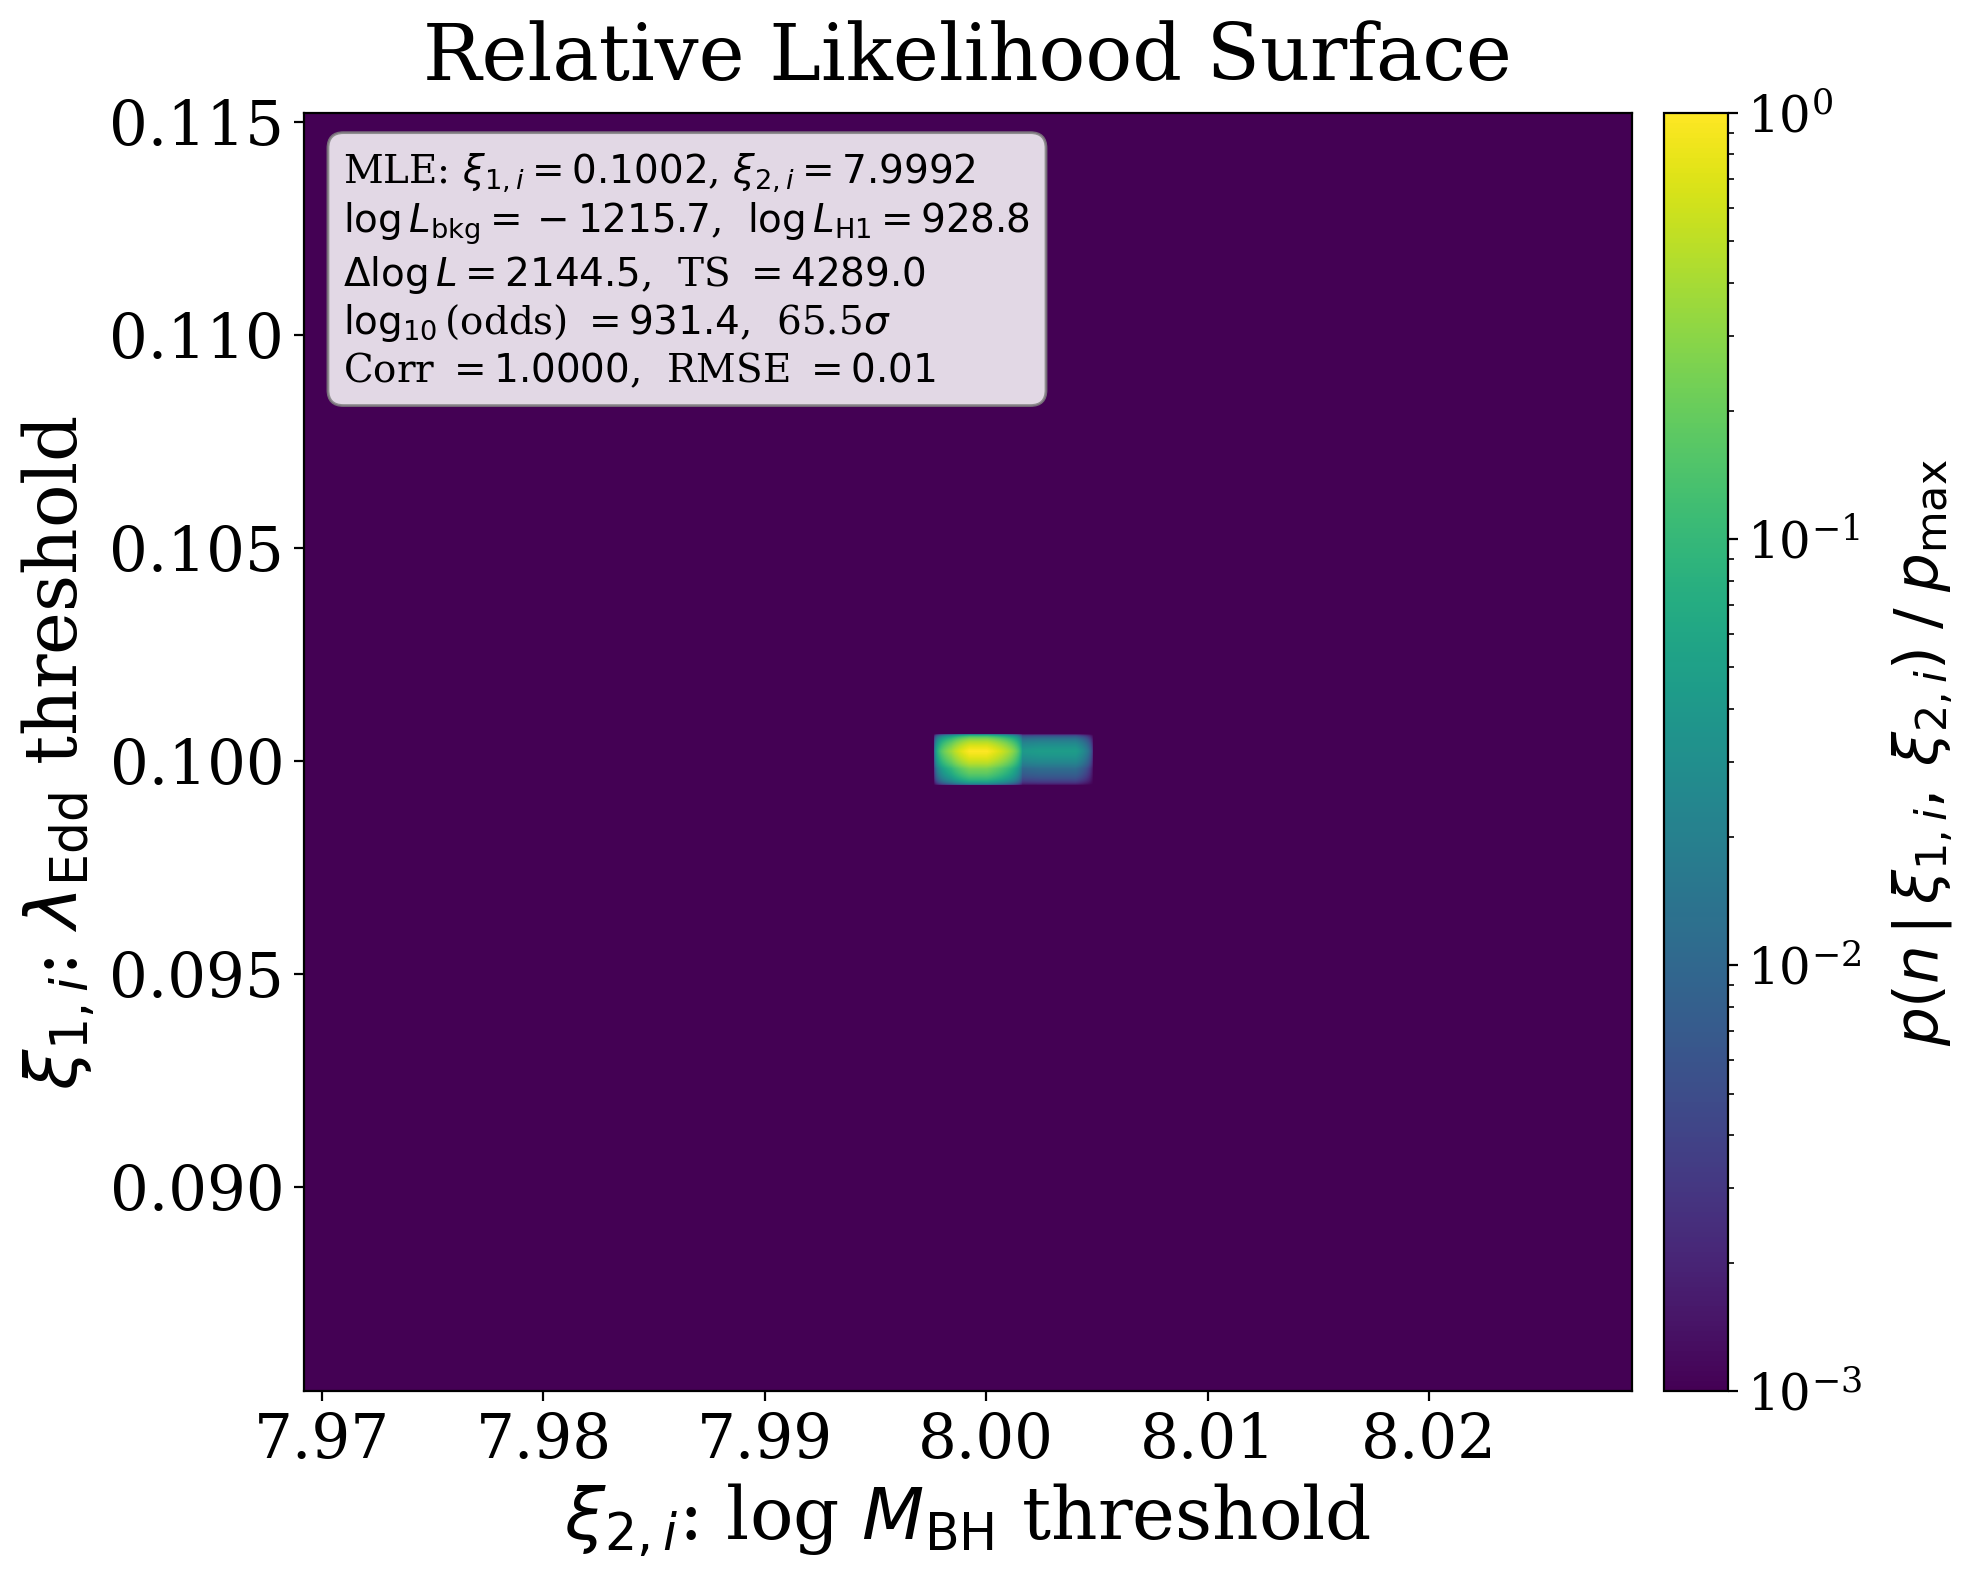

  MLE: ξ_{1,i} = 0.1002, ξ_{2,i} = 7.9992
  True: ξ_{1,i} = 0.1000, ξ_{2,i} = 8.00


In [91]:
# relative log likelihood surface 
from matplotlib.colors import LogNorm

# normalized likelihood: L / L_max  (clipped to [1e-3, 1])
# .T because fine_ll[j,i] has j→ξ_{2,i} (rows) and i→ξ_{1,i} (cols),
# but imshow maps rows→y and cols→x, so transpose to get x=ξ_{2,i}, y=ξ_{1,i}
lik_normalized = np.clip(10.0**fine_rel_log10, 1e-3, 1.0).T

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

im = ax.imshow(
    lik_normalized,
    origin='lower',
    extent=[fine_xi2_range.min(), fine_xi2_range.max(),
            fine_xi1_range.min(), fine_xi1_range.max()],
    cmap='viridis',
    norm=LogNorm(vmin=1e-3, vmax=1.0),
    aspect='auto',
    interpolation='bilinear'
)

# tighter zoom into the blob
ax.set_xlim(best_xi2 - 0.03, best_xi2 + 0.03)
ax.set_ylim(best_xi1 - 0.015, best_xi1 + 0.015)

ax.set_xlabel(r'$\xi_{2,i}$: log $M_{\rm BH}$ threshold', fontsize=26)
ax.set_ylabel(r'$\xi_{1,i}$: $\lambda_{\rm Edd}$ threshold', fontsize=26)
ax.set_title('Relative Likelihood Surface', fontsize=28, pad=12)
ax.tick_params(axis='both', labelsize=22)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r'$p(n\,|\,\xi_{1,i},\,\xi_{2,i})\;/\;p_{\rm max}$', fontsize=22, labelpad=10)
cbar.ax.tick_params(labelsize=18)

# comprehensive metrics annotation
if delta_log_L < 500:
    odds_str = f'{np.exp(delta_log_L):.2e}'
else:
    odds_str = rf'$\sim 10^{{{log10_odds:.0f}}}$'
info_text = (
    rf'MLE: $\xi_{{1,i}}={best_xi1:.4f}$, $\xi_{{2,i}}={best_xi2:.4f}$'
    '\n'
    rf'$\log L_{{\rm bkg}} = {log_L_bkg:.1f}$,  $\log L_{{\rm H1}} = {log_L_H1:.1f}$'
    '\n'
    rf'$\Delta\log L = {delta_log_L:.1f}$,  TS $= {TS:.1f}$'
    '\n'
    rf'$\log_{{10}}$(odds) $= {log10_odds:.1f}$,  {sigma_equiv:.1f}$\sigma$'
    '\n'
    rf'Corr $= {correlation:.4f}$,  RMSE $= {rmse:.2f}$'
)
ax.text(0.03, 0.97, info_text, transform=ax.transAxes,
        fontsize=14, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.savefig('step_model_likelihood_surface.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"  MLE: ξ_{{1,i}} = {best_xi1:.4f}, ξ_{{2,i}} = {best_xi2:.4f}")
print(f"  True: ξ_{{1,i}} = {true_e_ratio_thres:.4f}, ξ_{{2,i}} = {true_mbh_thres:.2f}")

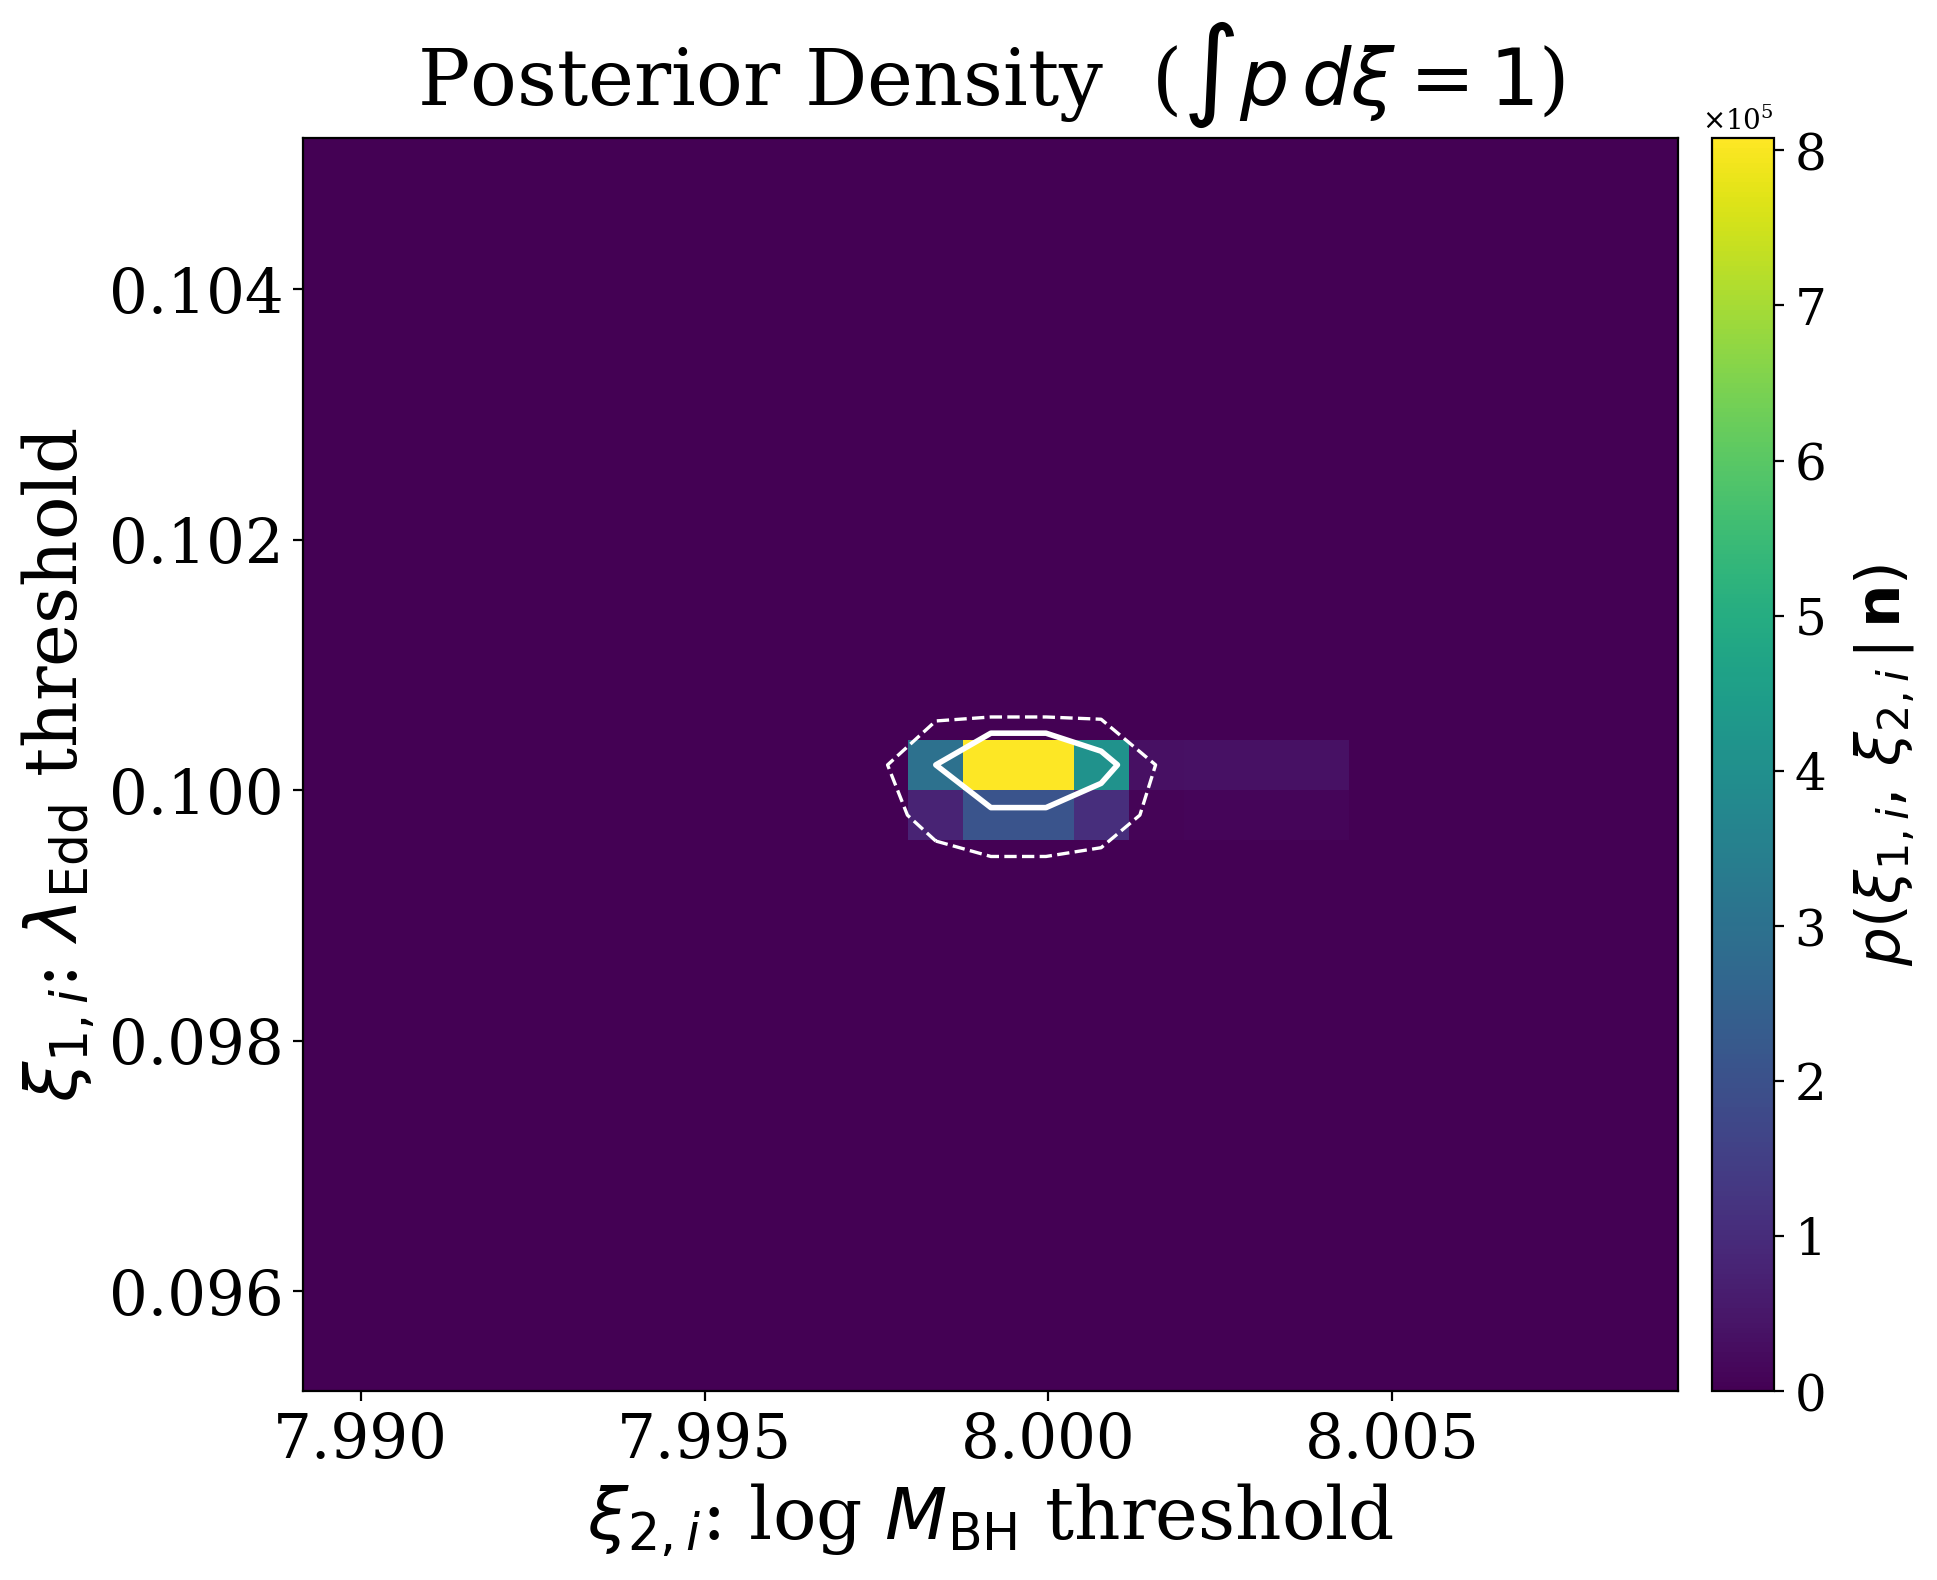

  Posterior integral = 1.000000 
  Peak density       = 8.08e+05

Odds Ratio Overview: Step Model

  Config: ξ_{1,i} (λ_Edd threshold) = 0.10,  ξ_{2,i} (log M_BH threshold) = 8.00
  norm = [1000, 10000],  bg = 2.0

  Metric                                        Value
  ----------------------------------- ---------------
  MLE ξ_{1,i}                                  0.1002
  MLE ξ_{2,i}                                  7.9992
  True ξ_{1,i}                                 0.1000
  True ξ_{2,i}                                   8.00
  log L(bkg)                                 -1215.74
  log L(H1)                                    928.79
  Δ log L                                     2144.52
  TS = 2ΔlogL                                 4289.04
  Odds Ratio                                  ~10^931
  log_10(odds ratio)                            931.4
  Gaussian-equiv σ                              65.5σ
  Correlation (MLE vs True)                    1.0000
  RMSE (MLE vs True)         

In [92]:
import matplotlib.ticker as ticker

# ── Credible regions on the properly normalized density (integral = 1) ──
flat_sorted = np.sort(posterior_density.ravel())[::-1]
cum_prob = np.cumsum(flat_sorted) * dxi1 * dxi2
level_68 = flat_sorted[np.searchsorted(cum_prob, 0.68)]
level_95 = flat_sorted[np.searchsorted(cum_prob, 0.95)]

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

# posterior_density has shape (n_xi2, n_xi1) → transpose so x = ξ₂, y = ξ₁
im = ax.pcolormesh(
    fine_xi2_range, fine_xi1_range,
    posterior_density.T,
    cmap='viridis',
    shading='auto',
    rasterized=True,
)

# Contour lines for 68% and 95% credible regions
ax.contour(
    fine_xi2_range, fine_xi1_range,
    posterior_density.T,
    levels=[level_95, level_68],
    colors=['white', 'white'],
    linewidths=[1.2, 2.0],
    linestyles=['dashed', 'solid'],
)

# zoom to the posterior blob
zoom_w = 0.01    # half-width in ξ₂
zoom_h = 0.005   # half-width in ξ₁
ax.set_xlim(best_xi2 - zoom_w, best_xi2 + zoom_w)
ax.set_ylim(best_xi1 - zoom_h, best_xi1 + zoom_h)

ax.set_xlabel(r'$\xi_{2,i}$: log $M_{\rm BH}$ threshold', fontsize=26)
ax.set_ylabel(r'$\xi_{1,i}$: $\lambda_{\rm Edd}$ threshold', fontsize=26)
ax.set_title(r'Posterior Density  ($\int p\,d\xi = 1$)', fontsize=28, pad=12)
ax.tick_params(axis='both', labelsize=22)

cbar = plt.colorbar(im, ax=ax, pad=0.02, format=ticker.ScalarFormatter(useMathText=True))
cbar.ax.ticklabel_format(style='scientific', scilimits=(0, 0))
cbar.set_label(r'$p(\xi_{1,i},\,\xi_{2,i}\,|\,\mathbf{n})$', fontsize=22, labelpad=10)
cbar.ax.tick_params(labelsize=18)

plt.tight_layout()
plt.savefig('step_model_posterior_density.png', dpi=200, bbox_inches='tight')
plt.show()

integral = np.sum(posterior_density) * dxi1 * dxi2
print(f"  Posterior integral = {integral:.6f} ")
print(f"  Peak density       = {posterior_density.max():.2e}")
print()

# odds Ratio Overview: Step Model
print("=" * 40)
print("Odds Ratio Overview: Step Model")
print("=" * 40)
print()
print(f"  Config: ξ_{{1,i}} (λ_Edd threshold) = {true_e_ratio_thres:.2f},  ξ_{{2,i}} (log M_BH threshold) = {true_mbh_thres:.2f}")
print(f"  norm = {norm},  bg = {bg}")
print()
print(f"  {'Metric':<35s} {'Value':>15s}")
print(f"  {'-'*35} {'-'*15}")
print(f"  {'MLE ξ_{1,i}':<35s} {best_xi1:>15.4f}")
print(f"  {'MLE ξ_{2,i}':<35s} {best_xi2:>15.4f}")
print(f"  {'True ξ_{1,i}':<35s} {true_e_ratio_thres:>15.4f}")
print(f"  {'True ξ_{2,i}':<35s} {true_mbh_thres:>15.2f}")
print(f"  {'log L(bkg)':<35s} {log_L_bkg:>15.2f}")
print(f"  {'log L(H1)':<35s} {log_L_H1:>15.2f}")
print(f"  {'Δ log L':<35s} {delta_log_L:>15.2f}")
print(f"  {'TS = 2ΔlogL':<35s} {TS:>15.2f}")
if delta_log_L < 500:
    print(f"  {'Odds Ratio':<35s} {np.exp(delta_log_L):>15.2e}")
else:
    print(f"  {'Odds Ratio':<35s} {'~10^' + f'{log10_odds:.0f}':>15s}")
print(f"  {'log_10(odds ratio)':<35s} {log10_odds:>15.1f}")
print(f"  {'Gaussian-equiv σ':<35s} {sigma_equiv:>14.1f}σ")
print(f"  {'Correlation (MLE vs True)':<35s} {correlation:>15.4f}")
print(f"  {'RMSE (MLE vs True)':<35s} {rmse:>15.4f}")
print()
print(f"  All favour H1 over H0 (background-only): YES")
print("=" * 80)